### Step 0: Installs and Imports

In [1]:
pip install keybert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [2]:
import re
import nltk
import pandas as pd
from transformers import pipeline
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from keybert import KeyBERT

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

### Step 1: Preprocessing

In [3]:
df_kpmg = pd.read_json("/content/scraped_data_kpmg.json")
df_kpmg['content'] = df_kpmg['content'] + df_kpmg['pdf_content']
df_pwc = pd.read_json("/content/scraped_data_pwc.json")

In [4]:
# Text preprocessing function
def preprocess_text(text):
    text = re.sub(r'\W+', ' ', text.lower())  # Remove special characters
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
    return " ".join(tokens)

In [5]:
# Apply preprocessing to all articles
df_kpmg['clean_content'] = df_kpmg['content'].apply(preprocess_text)
df_pwc['clean_content'] = df_pwc['content'].apply(preprocess_text)

In [6]:
print(len(df_kpmg))
df_kpmg.head()

8


,url,title,date,content,pdf_content,clean_content
0,https://kpmg.com/us/en/media/news/harnessing-t...,Harnessing the Value of Data,2025-04-10,Fresh thinking and actionable insights that ad...,Unlocking value with data products kpmg.com Ke...,fresh thinking actionable insights address cri...
1,https://kpmg.com/us/en/media/news/kpmg-google-...,KPMG Expands AI Alliance with Google Cloud to ...,2025-04-09,Fresh thinking and actionable insights that ad...,,fresh thinking actionable insights address cri...
2,https://kpmg.com/us/en/media/news/new-industri...,New Administration: Signals to Watch for in In...,2025-03-27,Fresh thinking and actionable insights that ad...,,fresh thinking actionable insights address cri...
3,https://kpmg.com/us/en/media/news/cfo-cio-part...,The CFO-CIO Partnership: Key to Driving AI Inn...,2025-03-19,Fresh thinking and actionable insights that ad...,KPMG 2025 CFO & CIO Collaboration Survey Surve...,fresh thinking actionable insights address cri...
4,https://kpmg.com/us/en/media/news/kpmg-risk-re...,The Majority of U.S. Organizations Reportedly ...,2025-03-11,Fresh thinking and actionable insights that ad...,KPMG Enterprise Risk & Resiliency Survey C-Sui...,fresh thinking actionable insights address cri...


In [7]:
print(len(df_pwc))
df_pwc.head()

9


,title,date,content,url,clean_content
0,agentic ai in the human capital management hcm...,2025-03-27,Agentic AI in the human capital management (HC...,https://www.pwc.in/ghost-templates/agentic-ai-...,agentic ai human capital management hcm indust...
1,making the case for global workforce migration,2025-03-27,Making the case for global workforce migration...,https://www.pwc.in/ghost-templates/making-the-...,making case global workforce migration strateg...
2,indian family offices the new investors for in...,2025-03-26,Indian family offices the new investors for In...,https://www.pwc.in/ghost-templates/indian-fami...,indian family offices new investors indias sta...
3,intergenerational trust the key to succession ...,2025-03-11,February 2025 Intergenerational trust: The key...,https://www.pwc.in/ghost-templates/intergenera...,february 2025 intergenerational trust key succ...
4,understanding the impact of genai on the india...,2025-03-10,Understanding the impact of GenAI on the India...,https://www.pwc.in/ghost-templates/understandi...,understanding impact genai indian healthcare e...


### Step 2: Classify Articles by Industry

In [8]:
print("hi")

hi


In [10]:
# Load a zero-shot classification model and various industries for classification
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
candidate_labels = ["Technology", "Healthcare", "Finance", "Retail", "Manufacturing", "Education", "Telecommunications", "Energy", "Transportation", "Real Estate", "Entertainment", "Hospitality", "Agriculture", "Aerospace", "Automotive", "Construction", "Media", "Legal", "Logistics", "Non-profit", "Environment", "Others"]

# Classify
df_kpmg['industry'] = df_kpmg['clean_content'].apply(lambda x: classifier(x, candidate_labels)['labels'][0])
df_pwc['industry'] = df_pwc['clean_content'].apply(lambda x: classifier(x, candidate_labels)['labels'][0])

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [11]:
df_kpmg.head()

,url,title,date,content,pdf_content,clean_content,industry
0,https://kpmg.com/us/en/media/news/harnessing-t...,Harnessing the Value of Data,2025-04-10,Fresh thinking and actionable insights that ad...,Unlocking value with data products kpmg.com Ke...,fresh thinking actionable insights address cri...,Real Estate
1,https://kpmg.com/us/en/media/news/kpmg-google-...,KPMG Expands AI Alliance with Google Cloud to ...,2025-04-09,Fresh thinking and actionable insights that ad...,,fresh thinking actionable insights address cri...,Others
2,https://kpmg.com/us/en/media/news/new-industri...,New Administration: Signals to Watch for in In...,2025-03-27,Fresh thinking and actionable insights that ad...,,fresh thinking actionable insights address cri...,Energy
3,https://kpmg.com/us/en/media/news/cfo-cio-part...,The CFO-CIO Partnership: Key to Driving AI Inn...,2025-03-19,Fresh thinking and actionable insights that ad...,KPMG 2025 CFO & CIO Collaboration Survey Surve...,fresh thinking actionable insights address cri...,Real Estate
4,https://kpmg.com/us/en/media/news/kpmg-risk-re...,The Majority of U.S. Organizations Reportedly ...,2025-03-11,Fresh thinking and actionable insights that ad...,KPMG Enterprise Risk & Resiliency Survey C-Sui...,fresh thinking actionable insights address cri...,Others


In [12]:
df_pwc.head()

,title,date,content,url,clean_content,industry
0,agentic ai in the human capital management hcm...,2025-03-27,Agentic AI in the human capital management (HC...,https://www.pwc.in/ghost-templates/agentic-ai-...,agentic ai human capital management hcm indust...,Technology
1,making the case for global workforce migration,2025-03-27,Making the case for global workforce migration...,https://www.pwc.in/ghost-templates/making-the-...,making case global workforce migration strateg...,Real Estate
2,indian family offices the new investors for in...,2025-03-26,Indian family offices the new investors for In...,https://www.pwc.in/ghost-templates/indian-fami...,indian family offices new investors indias sta...,Manufacturing
3,intergenerational trust the key to succession ...,2025-03-11,February 2025 Intergenerational trust: The key...,https://www.pwc.in/ghost-templates/intergenera...,february 2025 intergenerational trust key succ...,Logistics
4,understanding the impact of genai on the india...,2025-03-10,Understanding the impact of GenAI on the India...,https://www.pwc.in/ghost-templates/understandi...,understanding impact genai indian healthcare e...,Healthcare


### Step 3: Extract Keywords

In [13]:
# Initialize KeyBERT model
kw_model = KeyBERT()

# Define a function to extract keywords
def extract_keywords(text, top_n=10):
    try:
        # Extract top_n keywords and return them
        keywords = kw_model.extract_keywords(text, keyphrase_ngram_range=(1, 2), stop_words="english", top_n=top_n)
        return [keyword for keyword, score in keywords]
    except Exception as e:
        print(f"Error extracting keywords: {e}")
        return []

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
# Apply it
df_kpmg['keywords'] = df_kpmg['clean_content'].apply(lambda x: extract_keywords(x, top_n=10))
df_pwc['keywords'] = df_pwc['clean_content'].apply(lambda x: extract_keywords(x, top_n=10))

# Display the DataFrame with extracted keywords
print(df_kpmg[['title', 'keywords']])
print("\n")
print(df_pwc[['title', 'keywords']])

                                               title  \
0                       Harnessing the Value of Data   
1  KPMG Expands AI Alliance with Google Cloud to ...   
2  New Administration: Signals to Watch for in In...   
3  The CFO-CIO Partnership: Key to Driving AI Inn...   
4  The Majority of U.S. Organizations Reportedly ...   
5  Cybersecurity considerations 2024: Technology,...   
6  First 100 Days: Upcoming Regulatory Signals fo...   
7   6 Industry use cases for intelligent forecasting   

                                            keywords  
0  [industry insights, service insights, insights...  
1  [capabilities agents, deploys ai, agent capabi...  
2  [tariff developments, organize industry, under...  
3  [initiatives strategic, opportunity insight, d...  
4  [resiliency organizations, resilience organiza...  
5  [organizations increasingly, cybersecurity ins...  
6  [alliances kpmg, kpmg insights, firms kpmg, op...  
7  [industry driven, companies journey, organize ...  


### Step 4: Cluster Themes

In [15]:
# Generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings_kpmg = model.encode(df_kpmg['clean_content'].tolist())
embeddings_pwc = model.encode(df_pwc['clean_content'].tolist())

# Apply KMeans clustering
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df_kpmg['cluster'] = kmeans.fit_predict(embeddings_kpmg)
df_pwc['cluster'] = kmeans.fit_predict(embeddings_pwc)

# Map clusters back to source articles
cluster_mappings_kpmg = df_kpmg.groupby('cluster')['title'].apply(list).to_dict()
print(cluster_mappings_kpmg)

cluster_mappings_pwc = df_pwc.groupby('cluster')['title'].apply(list).to_dict()
print(cluster_mappings_pwc)

{0: ['New Administration: Signals to Watch for in Industrial Manufacturing & Auto'], 1: ['The Majority of U.S. Organizations Reportedly Not Prepared to Handle Increasing Risks Events, Broad Disruptions – New KPMG Risk & Resilience Survey', 'Cybersecurity considerations 2024: Technology, media and telecommunications'], 2: ['Harnessing the Value of Data', 'The CFO-CIO Partnership: Key to Driving AI Innovation', '6 Industry use cases for intelligent forecasting'], 3: ['First 100 Days: Upcoming Regulatory Signals for Industrial Manufacturing & Auto'], 4: ['KPMG Expands AI Alliance with Google Cloud to Support Industry Adoption of Agentspace and Deliver Multi-Agent AI Solutions']}
{0: ['indian family offices the new investors for indias startup ecosystem', 'intergenerational trust the key to succession in family business'], 1: ['making the case for global workforce migration', 'the mutual funds route to viksit bharat 2047', 'financial health transcending from access to impact'], 2: ['agenti

In [16]:
df_kpmg.head()

,url,title,date,content,pdf_content,clean_content,industry,keywords,cluster
0,https://kpmg.com/us/en/media/news/harnessing-t...,Harnessing the Value of Data,2025-04-10,Fresh thinking and actionable insights that ad...,Unlocking value with data products kpmg.com Ke...,fresh thinking actionable insights address cri...,Real Estate,"[industry insights, service insights, insights...",2
1,https://kpmg.com/us/en/media/news/kpmg-google-...,KPMG Expands AI Alliance with Google Cloud to ...,2025-04-09,Fresh thinking and actionable insights that ad...,,fresh thinking actionable insights address cri...,Others,"[capabilities agents, deploys ai, agent capabi...",4
2,https://kpmg.com/us/en/media/news/new-industri...,New Administration: Signals to Watch for in In...,2025-03-27,Fresh thinking and actionable insights that ad...,,fresh thinking actionable insights address cri...,Energy,"[tariff developments, organize industry, under...",0
3,https://kpmg.com/us/en/media/news/cfo-cio-part...,The CFO-CIO Partnership: Key to Driving AI Inn...,2025-03-19,Fresh thinking and actionable insights that ad...,KPMG 2025 CFO & CIO Collaboration Survey Surve...,fresh thinking actionable insights address cri...,Real Estate,"[initiatives strategic, opportunity insight, d...",2
4,https://kpmg.com/us/en/media/news/kpmg-risk-re...,The Majority of U.S. Organizations Reportedly ...,2025-03-11,Fresh thinking and actionable insights that ad...,KPMG Enterprise Risk & Resiliency Survey C-Sui...,fresh thinking actionable insights address cri...,Others,"[resiliency organizations, resilience organiza...",1


### Step 5: Visualizations

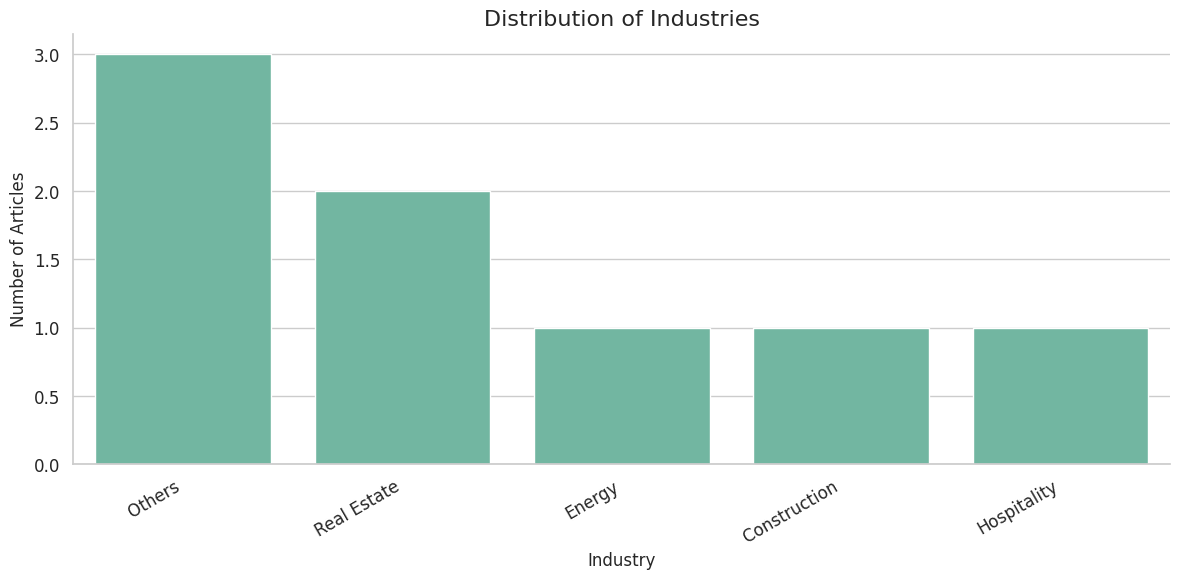

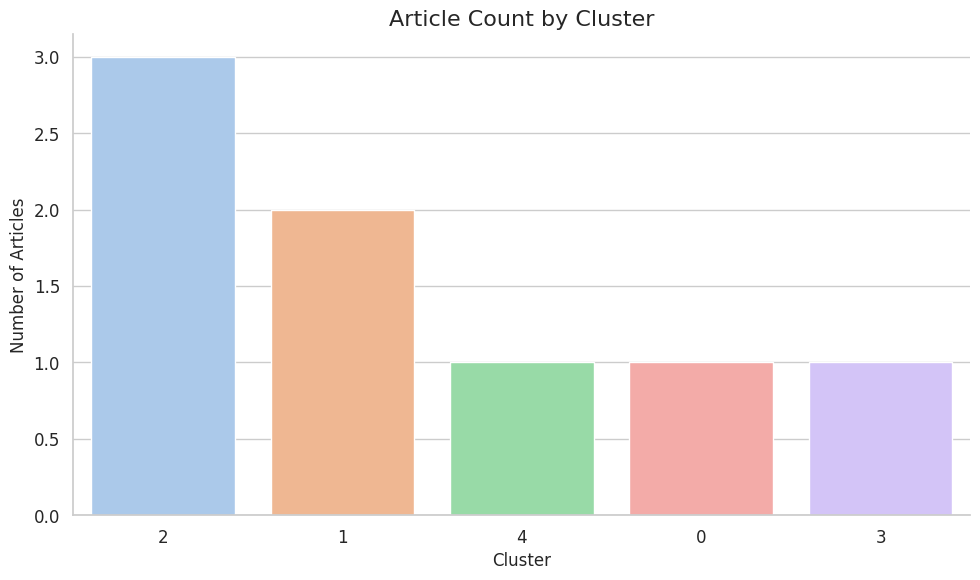

In [17]:
#Industry - kpmg
plt.figure(figsize=(12, 6))
sns.countplot(data=df_kpmg, x='industry', order=df_kpmg['industry'].value_counts().index)
plt.title("Distribution of Industries", fontsize=16)
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

#clusters - kpmg
plt.figure(figsize=(10, 6))
sns.countplot(data=df_kpmg, x='cluster', palette='pastel', order=df_kpmg['cluster'].value_counts().index)
plt.title("Article Count by Cluster", fontsize=16)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

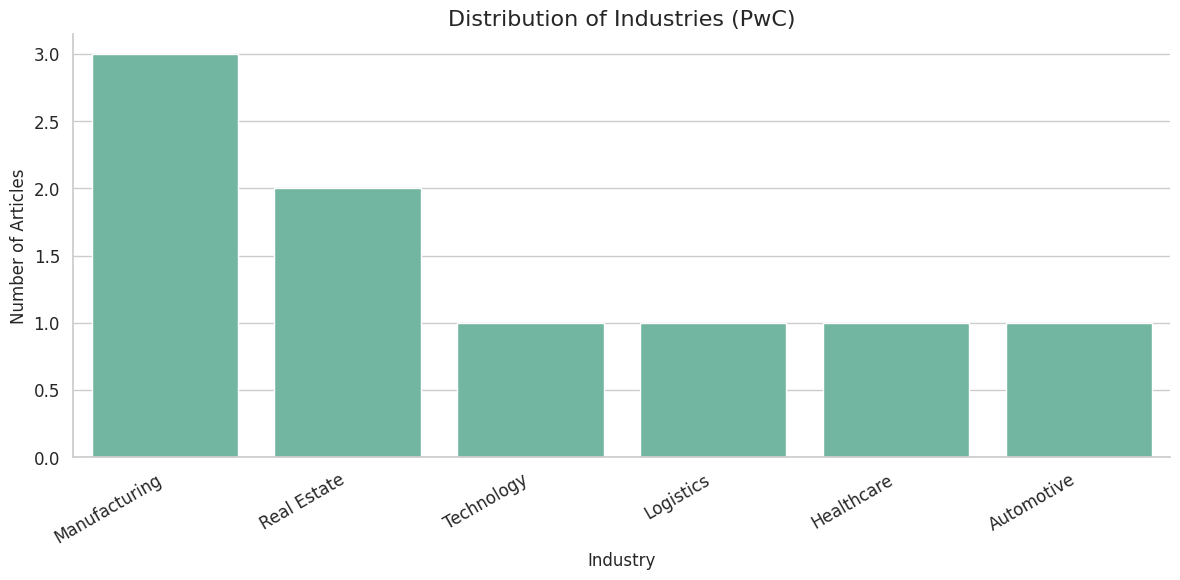

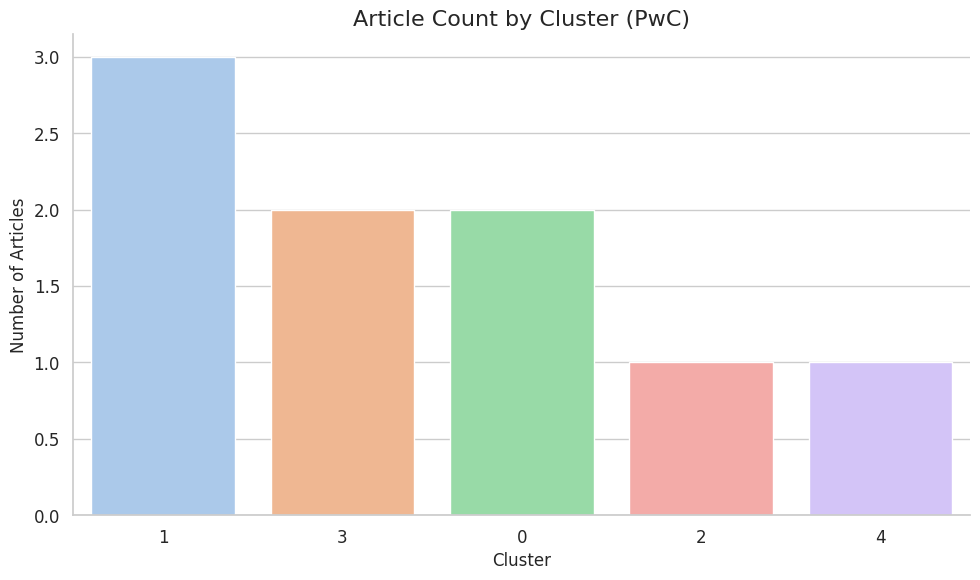

In [18]:
#industry - pwc
plt.figure(figsize=(12, 6))
sns.countplot(data=df_pwc, x='industry', order=df_pwc['industry'].value_counts().index)
plt.title("Distribution of Industries (PwC)", fontsize=16)
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

#clusters - pwc
plt.figure(figsize=(10, 6))
sns.countplot(data=df_pwc, x='cluster', palette='pastel', order=df_pwc['cluster'].value_counts().index)
plt.title("Article Count by Cluster (PwC)", fontsize=16)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

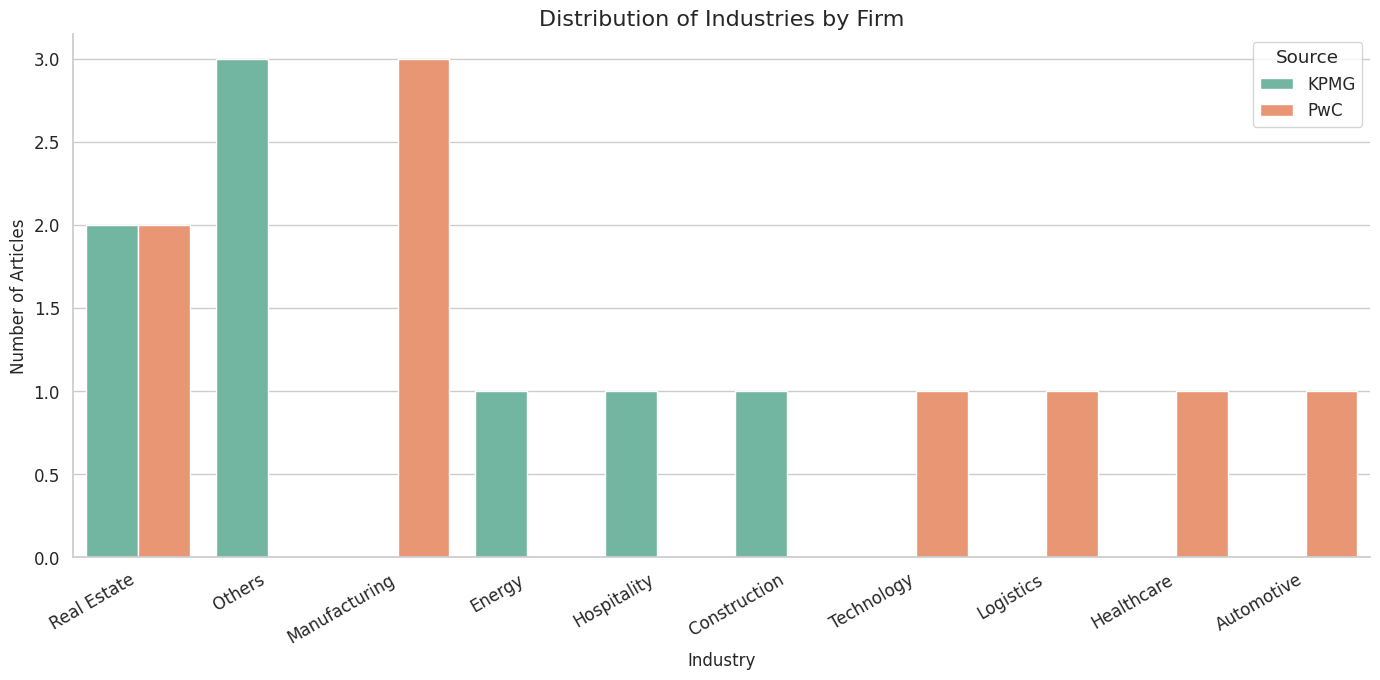

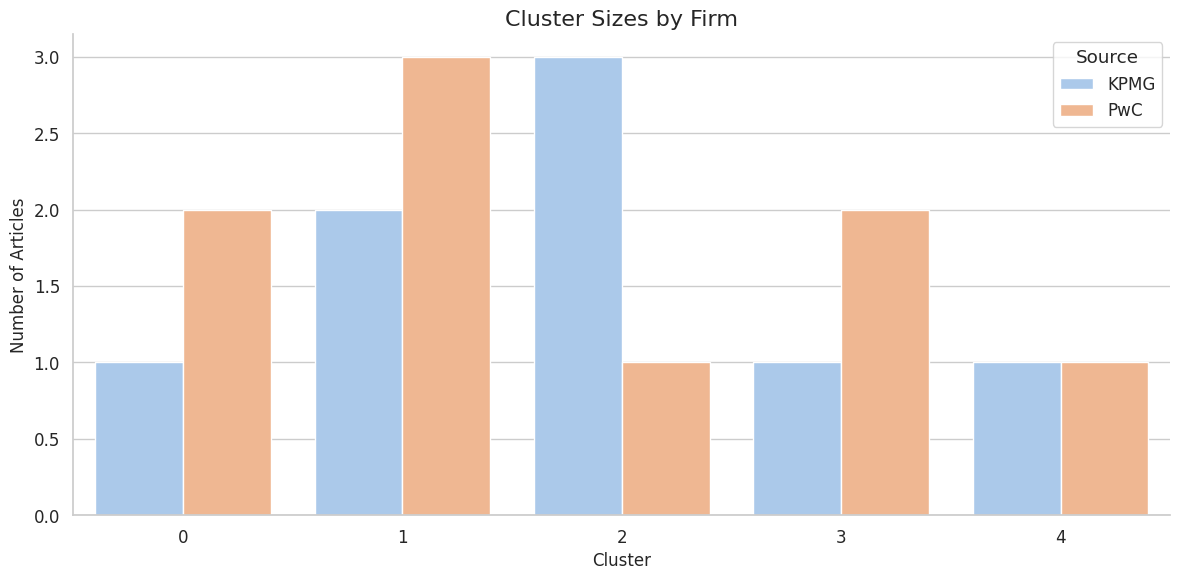

In [19]:
#Comparison
df_kpmg['source'] = 'KPMG'
df_pwc['source'] = 'PwC'

# Combine both into a single DataFrame
df_combined = pd.concat([df_kpmg, df_pwc], ignore_index=True)


plt.figure(figsize=(14, 7))
sns.countplot(data=df_combined, x='industry', hue='source', order=df_combined['industry'].value_counts().index)
plt.title("Distribution of Industries by Firm", fontsize=16)
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Source')
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=df_combined, x='cluster', hue='source', palette='pastel', order=sorted(df_combined['cluster'].unique()))
plt.title("Cluster Sizes by Firm", fontsize=16)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
plt.legend(title='Source')
sns.despine()
plt.tight_layout()
plt.show()

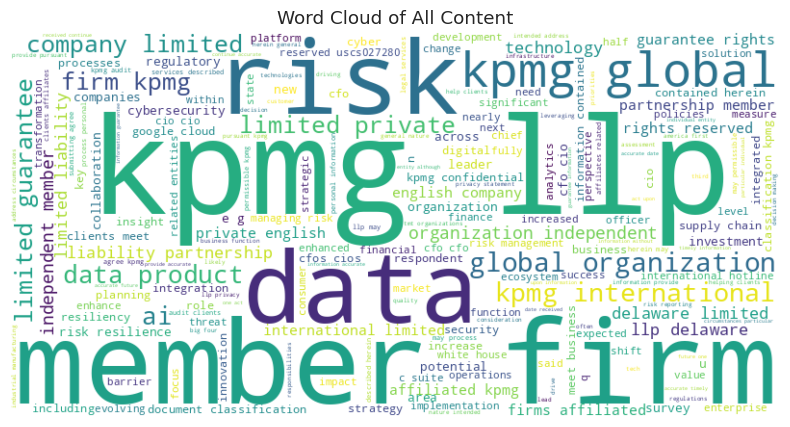

In [20]:
# Generate word cloud for all content - kpmg
text = " ".join(df_kpmg['clean_content'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of All Content")
plt.show()

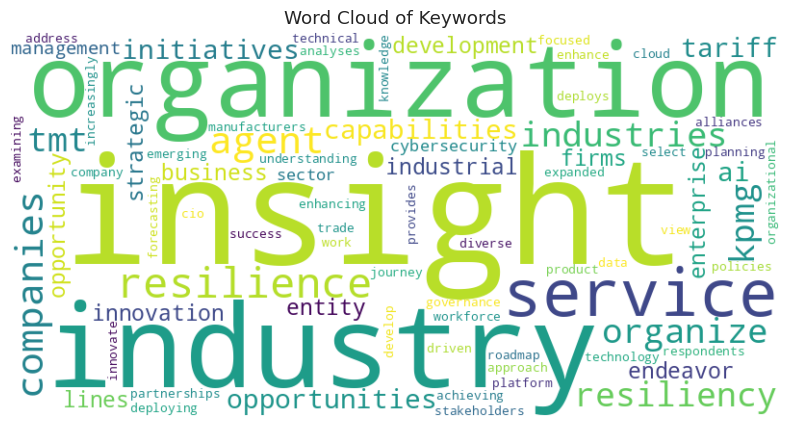

In [21]:
# Generate word cloud for keywords - kpmg
keywords_text = " ".join([" ".join(keywords) for keywords in df_kpmg['keywords']])
keyword_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(keywords_text)
plt.figure(figsize=(10, 5))
plt.imshow(keyword_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Keywords")
plt.show()

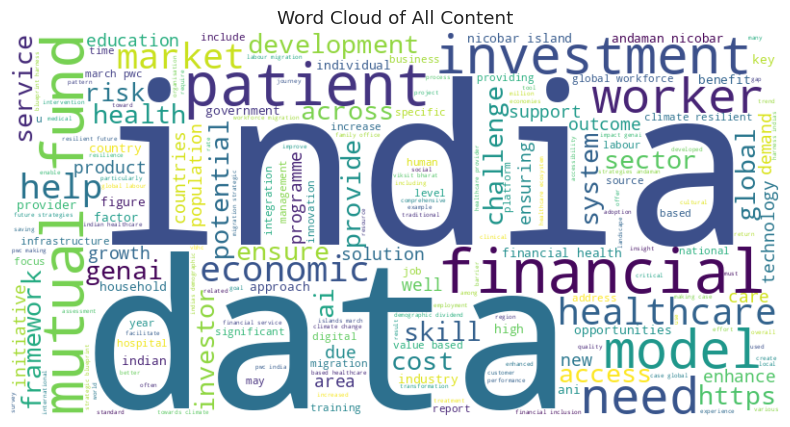

In [22]:
# Generate word cloud for all content - pwc
text = " ".join(df_pwc['clean_content'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of All Content")
plt.show()

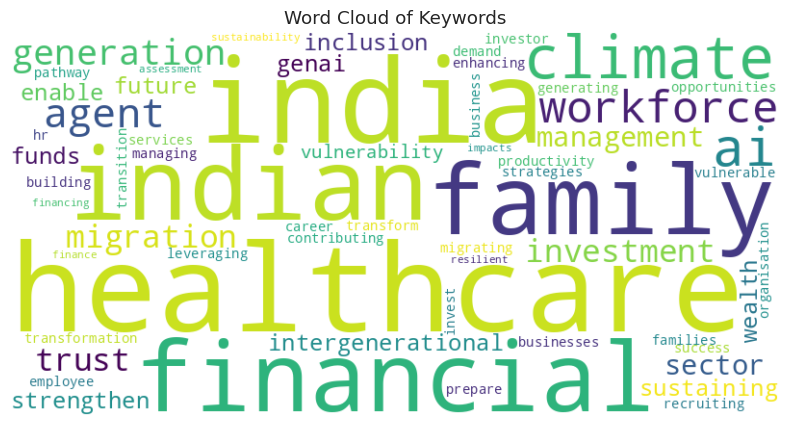

In [23]:
# Generate word cloud for keywords - pwc
keywords_text = " ".join([" ".join(keywords) for keywords in df_pwc['keywords']])
keyword_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(keywords_text)
plt.figure(figsize=(10, 5))
plt.imshow(keyword_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Keywords")
plt.show()